# MURA X-Ray Classification — EfficientNetB4 with Fine-Tuning
**Diploma Project:** Automatic Classification of Orthopedic X-ray Images Using Deep Learning

**Improvements over ResNet50 baseline:**
- EfficientNetB4 (more powerful architecture)
- 50 unfrozen layers in Phase 2 (vs 30 in ResNet)
- Label smoothing 0.1
- Test Time Augmentation (TTA)
- Optimized threshold selection

## 1. GPU Check and Imports

In [1]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU memory growth enabled for {len(gpus)} GPU(s)")

2026-03-31 10:08:08.831182: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774951689.077984      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774951689.146062      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774951689.685398      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774951689.685439      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774951689.685442      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✓ GPU memory growth enabled for 1 GPU(s)


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, warnings, random
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import load_img, img_to_array, ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)
print("✓ All libraries imported")
print("✓ Random seed set to 42")

✓ All libraries imported
✓ Random seed set to 42


## 2. Configuration

In [3]:

DATA_DIR = Path('/kaggle/input/datasets/cjinny/mura-v11/MURA-v1.1')

IMG_SIZE    = (224, 224)
IMG_SHAPE   = IMG_SIZE + (3,)
BATCH_SIZE  = 32

# Phase 1 — Feature Extraction (base frozen)
PHASE1_EPOCHS = 5
PHASE1_LR     = 1e-3

# Phase 2 — Fine-Tuning (unfreeze last N layers)
PHASE2_EPOCHS   = 30        # more epochs than ResNet
PHASE2_LR       = 1e-5
UNFREEZE_LAYERS = 50        # more than ResNet's 30

CHECKPOINT_PATH = '/kaggle/working/best_efficientnet.keras'

print("CONFIGURATION")
print(f"Model          : EfficientNetB4 (ImageNet pretrained)")
print(f"Dataset        : FULL MURA-v1.1")
print(f"Image size     : {IMG_SIZE}")
print(f"Batch size     : {BATCH_SIZE}")
print(f"Phase 1        : {PHASE1_EPOCHS} epochs, LR={PHASE1_LR}")
print(f"Phase 2        : {PHASE2_EPOCHS} epochs, LR={PHASE2_LR}")
print(f"Unfreeze layers: last {UNFREEZE_LAYERS} layers of EfficientNetB4")


CONFIGURATION
Model          : EfficientNetB4 (ImageNet pretrained)
Dataset        : FULL MURA-v1.1
Image size     : (224, 224)
Batch size     : 32
Phase 1        : 5 epochs, LR=0.001
Phase 2        : 30 epochs, LR=1e-05
Unfreeze layers: last 50 layers of EfficientNetB4


## 3. Load Dataset

In [4]:
def parse_mura_csv(csv_path):
    df = pd.read_csv(csv_path, header=None, names=['image_path'])
    df['label'] = df['image_path'].apply(
        lambda x: 1 if 'positive' in x else 0
    )
    df['body_part'] = df['image_path'].apply(
        lambda x: x.split('/')[2] if len(x.split('/')) > 2 else 'unknown'
    )
    df['image_path_clean'] = df['image_path'].apply(
        lambda x: x.replace('MURA-v1.1/', '')
    )
    return df

print("Loading FULL dataset...")
train_df = parse_mura_csv(DATA_DIR / 'train_image_paths.csv')
valid_df  = parse_mura_csv(DATA_DIR / 'valid_image_paths.csv')

print(f"\n✓ Train : {len(train_df):,} images")
print(f"✓ Valid : {len(valid_df):,} images")

vc = train_df['label'].value_counts()
print(f"\nClass distribution (train):")
print(f"  Normal   (0): {vc.get(0,0):,}  ({vc.get(0,0)/len(train_df)*100:.1f}%)")
print(f"  Abnormal (1): {vc.get(1,0):,}  ({vc.get(1,0)/len(train_df)*100:.1f}%)")
print(f"\nBy body part (train):")
print(train_df['body_part'].value_counts().to_string())

Loading FULL dataset...

✓ Train : 36,808 images
✓ Valid : 3,197 images

Class distribution (train):
  Normal   (0): 21,935  (59.6%)
  Abnormal (1): 14,873  (40.4%)

By body part (train):
body_part
XR_WRIST       9752
XR_SHOULDER    8379
XR_HAND        5543
XR_FINGER      5106
XR_ELBOW       4931
XR_FOREARM     1825
XR_HUMERUS     1272


## 4. Augmentation and Data Generators

In [5]:
# EfficientNet uses preprocess_input (scales to [-1, 1])
AUGMENTATION_CONFIG = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.85, 1.15],
    fill_mode='nearest'
)

print("✓ Augmentation configured:")
for k, v in AUGMENTATION_CONFIG.items():
    print(f"  {k}: {v}")

✓ Augmentation configured:
  rotation_range: 15
  width_shift_range: 0.1
  height_shift_range: 0.1
  shear_range: 0.1
  zoom_range: 0.1
  horizontal_flip: True
  brightness_range: [0.85, 1.15]
  fill_mode: nearest


In [6]:
def make_generator(df, base_dir, is_training=True, batch_size=BATCH_SIZE):
    aug = ImageDataGenerator(**AUGMENTATION_CONFIG) if is_training else None

    def _gen():
        indices = list(range(len(df)))
        while True:
            if is_training:
                random.shuffle(indices)
            for start in range(0, len(indices), batch_size):
                batch_idx = indices[start: start + batch_size]
                rows = df.iloc[batch_idx]
                images, labels = [], []
                for _, row in rows.iterrows():
                    path = base_dir / row['image_path_clean']
                    try:
                        img = load_img(path, target_size=IMG_SIZE, color_mode='rgb')
                        arr = img_to_array(img)
                        if is_training and aug:
                            arr = aug.random_transform(arr)
                        arr = preprocess_input(arr)  # EfficientNet normalization
                        images.append(arr)
                        labels.append(float(row['label']))
                    except Exception as e:
                        continue
                if images:
                    yield np.array(images, dtype=np.float32), np.array(labels, dtype=np.float32)

    return _gen()

train_gen   = make_generator(train_df, DATA_DIR, is_training=True)
valid_gen   = make_generator(valid_df, DATA_DIR, is_training=False)

TRAIN_STEPS = len(train_df) // BATCH_SIZE
VALID_STEPS = len(valid_df) // BATCH_SIZE

print(f"✓ Generators created")
print(f"  Train steps/epoch : {TRAIN_STEPS}")
print(f"  Valid steps       : {VALID_STEPS}")

✓ Generators created
  Train steps/epoch : 1150
  Valid steps       : 99


## 5. Model Architecture — EfficientNetB4

In [7]:
def build_efficientnet_model(input_shape=IMG_SHAPE):
    """
    EfficientNetB4 + custom classification head.
    Phase 1: base fully frozen.
    Phase 2: last UNFREEZE_LAYERS unfrozen.
    """
    base_model = EfficientNetB4(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape,
        pooling='avg'
    )
    base_model.trainable = False

    print(f"EfficientNetB4 loaded. Layers in base: {len(base_model.layers)}")
    print(f"All layers frozen for Phase 1.")

    inputs = keras.Input(shape=input_shape, name='input_xray')
    x = base_model(inputs, training=False)

    # Deeper classification head than ResNet version
    x = layers.Dropout(0.4, name='drop_1')(x)
    x = layers.Dense(512, activation='relu', name='dense_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.Dropout(0.3, name='drop_2')(x)
    x = layers.Dense(256, activation='relu', name='dense_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.Dropout(0.2, name='drop_3')(x)

    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    model = keras.Model(inputs, outputs, name='EfficientNetB4_MURA')
    return model, base_model

model, base_model = build_efficientnet_model(IMG_SHAPE)

total_params     = model.count_params()
trainable_params = sum([tf.size(v).numpy() for v in model.trainable_variables])
frozen_params    = total_params - trainable_params

print(f"MODEL: EfficientNetB4 + Custom Head")
print(f"Total parameters    : {total_params:,}")
print(f"Trainable (Phase 1) : {trainable_params:,}  (head only)")
print(f"Frozen              : {frozen_params:,}  (base EfficientNetB4)")


I0000 00:00:1774951717.519201      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
EfficientNetB4 loaded. Layers in base: 476
All layers frozen for Phase 1.
MODEL: EfficientNetB4 + Custom Head
Total parameters    : 18,726,496
Trainable (Phase 1) : 1,051,137  (head only)
Frozen              : 17,675,359  (base EfficientNetB4)


In [8]:
model.summary()

Model: "EfficientNetB4_MURA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_xray (InputLayer)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb4 (Functional)     │ (None, 1792)           │    17,673,823 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (Dropout)                │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       918,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (Dropout)                │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (Dropout)                │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,726,496 (71.44 MB)

 Trainable params: 1,051,137 (4.01 MB)

 Non-trainable params: 17,675,359 (67.43 MB)

## 6. Class Weights and Weighted Loss

In [9]:
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=train_df['label'].values
)
CLASS_WEIGHT_DICT = {0: class_weights_arr[0], 1: class_weights_arr[1]}

print("✓ Class weights calculated:")
print(f"  Normal   (0): {CLASS_WEIGHT_DICT[0]:.4f}")
print(f"  Abnormal (1): {CLASS_WEIGHT_DICT[1]:.4f}")
print(f"  Ratio: {CLASS_WEIGHT_DICT[1]/CLASS_WEIGHT_DICT[0]:.2f}x in favor of minority class")

# Weighted loss — works with Python generators (unlike class_weight argument)
w0 = float(CLASS_WEIGHT_DICT[0])
w1 = float(CLASS_WEIGHT_DICT[1])

def weighted_bce(y_true, y_pred):
    # Label smoothing 0.1 — reduces overconfidence
    y_true_smooth = y_true * 0.9 + 0.05
    bce = keras.losses.binary_crossentropy(y_true_smooth, y_pred)
    weight = y_true * w1 + (1 - y_true) * w0
    return keras.ops.mean(weight * bce)

print("✓ Weighted loss with label smoothing (0.1) defined")

✓ Class weights calculated:
  Normal   (0): 0.8390
  Abnormal (1): 1.2374
  Ratio: 1.47x in favor of minority class
✓ Weighted loss with label smoothing (0.1) defined


## 7. Phase 1 — Feature Extraction (base frozen)

In [10]:
model, base_model = build_efficientnet_model(input_shape=IMG_SHAPE)

model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE1_LR),
    loss=weighted_bce,
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc', curve='ROC')
    ]
)

callbacks_phase1 = [
    callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    ),
    callbacks.CSVLogger('/kaggle/working/phase1_log.csv')
]

print("PHASE 1 — FEATURE EXTRACTION")
print(f"Epochs: {PHASE1_EPOCHS} | LR: {PHASE1_LR} | Base: frozen")

t0 = time.time()
history_phase1 = model.fit(
    train_gen,
    steps_per_epoch=TRAIN_STEPS,
    epochs=PHASE1_EPOCHS,
    validation_data=valid_gen,
    validation_steps=VALID_STEPS,
    callbacks=callbacks_phase1,
    verbose=1
)

print(f"\nPhase 1 done in {(time.time()-t0)/60:.1f} min")
print(f"Best val_auc: {max(history_phase1.history['val_auc']):.4f}")

EfficientNetB4 loaded. Layers in base: 476
All layers frozen for Phase 1.
PHASE 1 — FEATURE EXTRACTION
Epochs: 5 | LR: 0.001 | Base: frozen
Epoch 1/5


I0000 00:00:1774951746.760121     122 service.cc:152] XLA service 0x7fb5bc002190 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774951746.760157     122 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774951751.333156     122 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774951774.452452     122 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 880ms/step - accuracy: 0.6385 - auc: 0.6633 - loss: 0.7072 - precision: 0.5618 - recall: 0.5058
Epoch 1: val_auc improved from -inf to 0.77046, saving model to /kaggle/working/best_efficientnet.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 1118s 930ms/step - accuracy: 0.6385 - auc: 0.6633 - loss: 0.7072 - precision: 0.5619 - recall: 0.5058 - val_accuracy: 0.6998 - val_auc: 0.7705 - val_loss: 0.6404 - val_precision: 0.7749 - val_recall: 0.5333 - learning_rate: 0.0010
Epoch 2/5
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.7001 - auc: 0.7423 - loss: 0.6055 - precision: 0.6699 - recall: 0.5191
Epoch 2: val_auc improved from 0.77046 to 0.79659, saving model to /kaggle/working/best_efficientnet.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 685s 574ms/step - accuracy: 0.7001 - auc: 0.7423 - loss: 0.6055 - precision: 0.6699 - recall: 0.5191 - val_accuracy: 0.7165 - val_auc: 0.7966 - val_loss: 0.6260 - val_precision: 0.8264 - val_recall: 0.5372 - learning_rate: 0.0

## 8. Phase 2 — Fine-Tuning (unfreeze last 50 layers)

In [11]:
print(f"Total layers in EfficientNetB4: {len(base_model.layers)}")
for i, layer in enumerate(base_model.layers[-10:]):
    print(f"  Layer {len(base_model.layers)-10+i}: {layer.name}")

Total layers in EfficientNetB4: 476
  Layer 466: block7b_se_expand
  Layer 467: block7b_se_excite
  Layer 468: block7b_project_conv
  Layer 469: block7b_project_bn
  Layer 470: block7b_drop
  Layer 471: block7b_add
  Layer 472: top_conv
  Layer 473: top_bn
  Layer 474: top_activation
  Layer 475: avg_pool


In [12]:
# Unfreeze last UNFREEZE_LAYERS layers
base_model.trainable = True
freeze_until = len(base_model.layers) - UNFREEZE_LAYERS

for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

# Keep BatchNorm in frozen part in inference mode
for layer in base_model.layers[:freeze_until]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_after = sum([tf.size(v).numpy() for v in model.trainable_variables])
total_params    = model.count_params()

print(f"✓ Unfreezing done")
print(f"  Frozen layers    : {freeze_until} (out of {len(base_model.layers)})")
print(f"  Unfrozen layers  : {UNFREEZE_LAYERS}")
print(f"  Trainable params : {trainable_after:,} / {total_params:,}")
print(f"  ({trainable_after/total_params*100:.1f}% of all parameters)")

✓ Unfreezing done
  Frozen layers    : 426 (out of 476)
  Unfrozen layers  : 50
  Trainable params : 7,487,417 / 18,726,496
  (40.0% of all parameters)


In [13]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=PHASE2_LR),
    loss=weighted_bce,
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc', curve='ROC')
    ]
)

callbacks_phase2 = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,           # more patience than ResNet
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath=CHECKPOINT_PATH,
        monitor='val_auc',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=4,
        min_lr=1e-8,
        verbose=1
    ),
    callbacks.CSVLogger('/kaggle/working/phase2_log.csv')
]

print("PHASE 2 — FINE-TUNING")
print(f"Epochs: {PHASE2_EPOCHS} | LR: {PHASE2_LR} | Unfrozen: {UNFREEZE_LAYERS} layers")

# Recreate generators
train_gen = make_generator(train_df, DATA_DIR, is_training=True)
valid_gen = make_generator(valid_df, DATA_DIR, is_training=False)

t0 = time.time()
history_phase2 = model.fit(
    train_gen,
    steps_per_epoch=TRAIN_STEPS,
    epochs=PHASE2_EPOCHS,
    validation_data=valid_gen,
    validation_steps=VALID_STEPS,
    callbacks=callbacks_phase2,
    verbose=1
)

print(f"\nPhase 2 done in {(time.time()-t0)/60:.1f} min")
print(f"Best val_auc: {max(history_phase2.history['val_auc']):.4f}")

PHASE 2 — FINE-TUNING
Epochs: 30 | LR: 1e-05 | Unfrozen: 50 layers
Epoch 1/30


2026-03-31 11:12:32.971261: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:12:33.200200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:12:33.643201: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:12:33.872717: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:12:34.489217: E external/local_xla/xla/stream_

1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.7110 - auc: 0.7532 - loss: 0.5963 - precision: 0.6726 - recall: 0.5365
Epoch 1: val_auc improved from -inf to 0.80323, saving model to /kaggle/working/best_efficientnet.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 744s 599ms/step - accuracy: 0.7110 - auc: 0.7532 - loss: 0.5963 - precision: 0.6726 - recall: 0.5365 - val_accuracy: 0.7153 - val_auc: 0.8032 - val_loss: 0.6342 - val_precision: 0.8165 - val_recall: 0.5294 - learning_rate: 1.0000e-05
Epoch 2/30


2026-03-31 11:24:32.038300: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 11:24:32.265508: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 574ms/step - accuracy: 0.7371 - auc: 0.7926 - loss: 0.5673 - precision: 0.7220 - recall: 0.5695
Epoch 2: val_auc improved from 0.80323 to 0.81793, saving model to /kaggle/working/best_efficientnet.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 711s 594ms/step - accuracy: 0.7371 - auc: 0.7926 - loss: 0.5673 - precision: 0.7220 - recall: 0.5695 - val_accuracy: 0.7364 - val_auc: 0.8179 - val_loss: 0.6276 - val_precision: 0.8537 - val_recall: 0.5609 - learning_rate: 1.0000e-05
Epoch 3/30
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.7468 - auc: 0.8014 - loss: 0.5599 - precision: 0.7349 - recall: 0.5851
Epoch 3: val_auc improved from 0.81793 to 0.82723, saving model to /kaggle/working/best_efficientnet.keras
1150/1150 ━━━━━━━━━━━━━━━━━━━━ 695s 605ms/step - accuracy: 0.7468 - auc: 0.8014 - loss: 0.5599 - precision: 0.7349 - recall: 0.5851 - val_accuracy: 0.7396 - val_auc: 0.8272 - val_loss: 0.6271 - val_precision: 0.8663 - val_recall: 0.5697 - learning_ra

## 9. Training Visualization

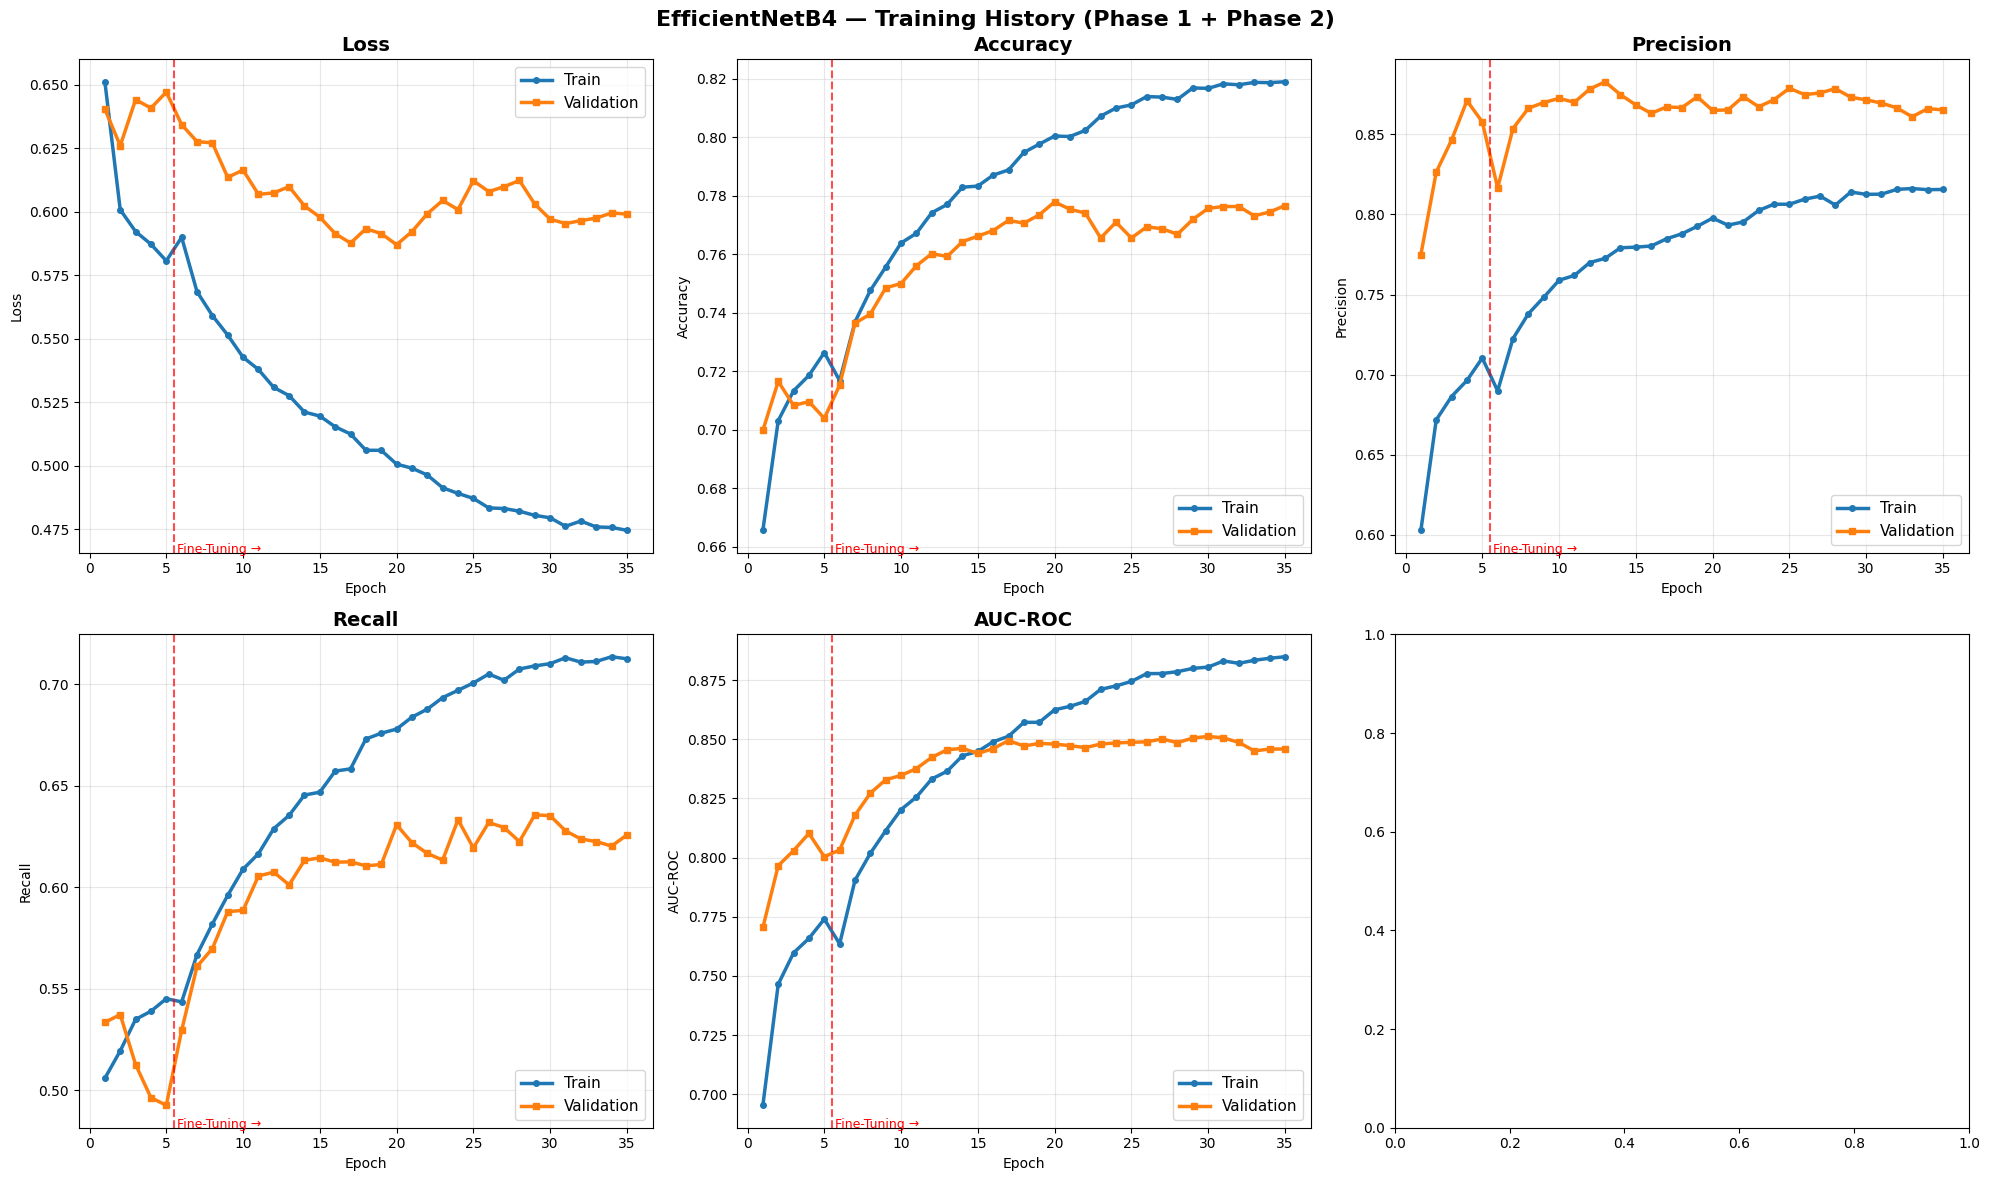

✓ Plot saved


In [14]:
def merge_history(h1, h2):
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

combined = merge_history(history_phase1, history_phase2)
phase1_end = PHASE1_EPOCHS

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
metrics_to_plot = [
    ('loss',      'Loss',      'min'),
    ('accuracy',  'Accuracy',  'max'),
    ('precision', 'Precision', 'max'),
    ('recall',    'Recall',    'max'),
    ('auc',       'AUC-ROC',   'max'),
]

for idx, (metric, title, mode) in enumerate(metrics_to_plot):
    ax = axes[idx // 3][idx % 3]
    epochs = range(1, len(combined[metric]) + 1)
    ax.plot(epochs, combined[metric],          label='Train',      lw=2.5, marker='o', markersize=4)
    ax.plot(epochs, combined[f'val_{metric}'], label='Validation', lw=2.5, marker='s', markersize=4)
    ax.axvline(x=phase1_end + 0.5, color='red', linestyle='--', alpha=0.7, lw=1.5)
    ax.text(phase1_end + 0.7, ax.get_ylim()[0], 'Fine-Tuning →', color='red', fontsize=9)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

ax = axes[1][2]
if 'lr' in combined:
    ax.plot(range(1, len(combined['lr'])+1), combined['lr'], lw=2, color='purple', marker='D', markersize=4)
    ax.axvline(x=phase1_end + 0.5, color='red', linestyle='--', alpha=0.7)
    ax.set_yscale('log')
    ax.set_title('Learning Rate', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('LR (log scale)')
    ax.grid(True, alpha=0.3)

plt.suptitle('EfficientNetB4 — Training History (Phase 1 + Phase 2)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_history_efficientnet.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Plot saved")

## 10. Load Best Model and Collect Predictions

In [15]:
print("Loading best model from checkpoint...")
best_model = keras.models.load_model(
    CHECKPOINT_PATH,
    custom_objects={'weighted_bce': weighted_bce}
)
print(f"✓ Model loaded: {CHECKPOINT_PATH}")

Loading best model from checkpoint...
✓ Model loaded: /kaggle/working/best_efficientnet.keras


In [16]:
print("Collecting validation data for evaluation...")

eval_gen = make_generator(valid_df, DATA_DIR, is_training=False, batch_size=BATCH_SIZE)

all_images, all_labels = [], []
for _ in range(VALID_STEPS):
    imgs, labs = next(eval_gen)
    all_images.append(imgs)
    all_labels.append(labs)

X_val = np.concatenate(all_images, axis=0)
y_val = np.concatenate(all_labels, axis=0)

print(f"✓ Collected {len(y_val):,} images")
print(f"  Normal   : {(y_val==0).sum():,}")
print(f"  Abnormal : {(y_val==1).sum():,}")

✓ Collected 3,168 images
  Normal   : 1,638
  Abnormal : 1,530


In [17]:
print("Generating predictions (standard)...")
y_pred_proba = best_model.predict(X_val, batch_size=BATCH_SIZE, verbose=1).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)
print(f"✓ Predictions done")
print(f"  Predicted Normal   : {(y_pred==0).sum():,}")
print(f"  Predicted Abnormal : {(y_pred==1).sum():,}")

Generating predictions (standard)...
99/99 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step
✓ Predictions done
  Predicted Normal   : 2,065
  Predicted Abnormal : 1,103


## 11. Final Metrics (standard threshold 0.5)

In [18]:
accuracy  = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall    = recall_score(y_val, y_pred)
f1        = f1_score(y_val, y_pred)
auc_roc   = roc_auc_score(y_val, y_pred_proba)

print("  FINAL RESULTS — EfficientNetB4 Fine-Tuned")
print(f"  Validation images : {len(y_val):,}")
print("-" * 60)
print(f"  Accuracy          : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision         : {precision:.4f}")
print(f"  Recall            : {recall:.4f}")
print(f"  F1-Score          : {f1:.4f}")
print(f"  AUC-ROC           : {auc_roc:.4f}")
print("-" * 60)
print(f"  Target metrics:")
print(f"  Accuracy ≥ 80%    : {'✓ PASS' if accuracy >= 0.80 else '✗ FAIL'}  ({accuracy*100:.2f}%)")
print(f"  AUC-ROC  ≥ 0.85   : {'✓ PASS' if auc_roc >= 0.85 else '✗ FAIL'}  ({auc_roc:.4f})")
print(f"  Recall   ≥ 75%    : {'✓ PASS' if recall >= 0.75 else '✗ FAIL'}  ({recall*100:.2f}%)")


  FINAL RESULTS — EfficientNetB4 Fine-Tuned
  Validation images : 3,168
------------------------------------------------------------
  Accuracy          : 0.7737  (77.37%)
  Precision         : 0.8685
  Recall            : 0.6261
  F1-Score          : 0.7277
  AUC-ROC           : 0.8469
------------------------------------------------------------
  Target metrics:
  Accuracy ≥ 80%    : ✗ FAIL  (77.37%)
  AUC-ROC  ≥ 0.85   : ✗ FAIL  (0.8469)
  Recall   ≥ 75%    : ✗ FAIL  (62.61%)


## 12. Threshold Optimization

In [19]:
print("Testing different thresholds:\n")
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Recall':>10} | {'Precision':>10} | {'F1':>10}")
print("-" * 60)

best_f1 = 0
best_threshold = 0.5

for threshold in [0.50, 0.45, 0.40, 0.38, 0.35, 0.32, 0.28]:
    y_pred_t = (y_pred_proba >= threshold).astype(int)
    acc = accuracy_score(y_val, y_pred_t)
    rec = recall_score(y_val, y_pred_t)
    pre = precision_score(y_val, y_pred_t)
    f1t = f1_score(y_val, y_pred_t)
    marker = ' ← best F1' if f1t > best_f1 else ''
    if f1t > best_f1:
        best_f1 = f1t
        best_threshold = threshold
    print(f"{threshold:>10.2f} | {acc:>10.4f} | {rec:>10.4f} | {pre:>10.4f} | {f1t:>10.4f}{marker}")

print(f"\n✓ Best threshold: {best_threshold}")

Testing different thresholds:

 Threshold |   Accuracy |     Recall |  Precision |         F1
------------------------------------------------------------
      0.50 |     0.7737 |     0.6261 |     0.8685 |     0.7277 ← best F1
      0.45 |     0.7797 |     0.6542 |     0.8556 |     0.7415 ← best F1
      0.40 |     0.7819 |     0.6843 |     0.8343 |     0.7519 ← best F1
      0.38 |     0.7809 |     0.6915 |     0.8266 |     0.7530 ← best F1
      0.35 |     0.7797 |     0.7111 |     0.8095 |     0.7571 ← best F1
      0.32 |     0.7765 |     0.7301 |     0.7911 |     0.7593 ← best F1
      0.28 |     0.7781 |     0.7621 |     0.7748 |     0.7684 ← best F1

✓ Best threshold: 0.28


## 13. TTA — Test Time Augmentation

In [20]:
def predict_with_tta(model, images, n_augments=10):
    tta_aug = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.05,
        height_shift_range=0.05,
        horizontal_flip=True,
        zoom_range=0.05
    )
    all_preds = []
    for i in range(n_augments):
        print(f"  TTA iteration {i+1}/{n_augments}...", end='\r')
        aug_images = np.array([tta_aug.random_transform(img) for img in images])
        preds = model.predict(aug_images, batch_size=BATCH_SIZE, verbose=0)
        all_preds.append(preds)
    tta_proba = np.mean(all_preds, axis=0).flatten()
    return tta_proba

print("Running TTA (10 augmentations, ~10 min)...")
y_pred_proba_tta = predict_with_tta(best_model, X_val, n_augments=10)

print("\nTTA results at different thresholds:")
print(f"{'Threshold':>10} | {'Accuracy':>10} | {'Recall':>10} | {'Precision':>10} | {'F1':>10} | {'AUC':>8}")
print("-" * 70)

auc_tta = roc_auc_score(y_val, y_pred_proba_tta)
for threshold in [0.50, 0.45, 0.40, 0.35, 0.32, 0.28]:
    y_pred_t = (y_pred_proba_tta >= threshold).astype(int)
    acc = accuracy_score(y_val, y_pred_t)
    rec = recall_score(y_val, y_pred_t)
    pre = precision_score(y_val, y_pred_t)
    f1t = f1_score(y_val, y_pred_t)
    print(f"{threshold:>10.2f} | {acc:>10.4f} | {rec:>10.4f} | {pre:>10.4f} | {f1t:>10.4f} | {auc_tta:>8.4f}")

Running TTA (10 augmentations, ~10 min)...
  TTA iteration 10/10...
TTA results at different thresholds:
 Threshold |   Accuracy |     Recall |  Precision |         F1 |      AUC
----------------------------------------------------------------------
      0.50 |     0.7907 |     0.6725 |     0.8640 |     0.7563 |   0.8595
      0.45 |     0.7961 |     0.7072 |     0.8453 |     0.7701 |   0.8595
      0.40 |     0.7961 |     0.7458 |     0.8162 |     0.7794 |   0.8595
      0.35 |     0.7904 |     0.7791 |     0.7852 |     0.7822 |   0.8595
      0.32 |     0.7828 |     0.7928 |     0.7658 |     0.7791 |   0.8595
      0.28 |     0.7689 |     0.8203 |     0.7331 |     0.7742 |   0.8595


## 14. Final Results with TTA

In [21]:
# Choose best threshold based on TTA results
FINAL_THRESHOLD = 0.35  # adjust after seeing TTA results above

y_pred_final = (y_pred_proba_tta >= FINAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm.ravel()

final_accuracy  = accuracy_score(y_val, y_pred_final)
final_precision = precision_score(y_val, y_pred_final)
final_recall    = recall_score(y_val, y_pred_final)
final_f1        = f1_score(y_val, y_pred_final)
final_auc       = roc_auc_score(y_val, y_pred_proba_tta)

print("  FINAL RESULTS — EfficientNetB4 (TTA + threshold optimized)")
print(f"  Threshold         : {FINAL_THRESHOLD}")
print(f"  Accuracy          : {final_accuracy:.4f}  ({final_accuracy*100:.2f}%)")
print(f"  Precision         : {final_precision:.4f}")
print(f"  Recall            : {final_recall:.4f}")
print(f"  F1-Score          : {final_f1:.4f}")
print(f"  AUC-ROC           : {final_auc:.4f}")
print("-" * 60)
print(f"  Fractures found correctly : {tp} out of {tp+fn}")
print(f"  Fractures missed          : {fn} out of {tp+fn} ({fn/(tp+fn)*100:.1f}%)")
print(f"  False alarms              : {fp}")
print(f"  Target metrics:")
print(f"  Accuracy ≥ 80%    : {'✓ PASS' if final_accuracy >= 0.80 else '✗ FAIL'}  ({final_accuracy*100:.2f}%)")
print(f"  AUC-ROC  ≥ 0.85   : {'✓ PASS' if final_auc >= 0.85 else '✗ FAIL'}  ({final_auc:.4f})")
print(f"  Recall   ≥ 75%    : {'✓ PASS' if final_recall >= 0.75 else '✗ FAIL'}  ({final_recall*100:.2f}%)")

# Save metrics for comparison notebook
results = {
    'model': 'EfficientNetB4_TTA',
    'threshold': FINAL_THRESHOLD,
    'accuracy': final_accuracy,
    'precision': final_precision,
    'recall': final_recall,
    'f1': final_f1,
    'auc_roc': final_auc,
    'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)
}
pd.DataFrame([results]).to_csv('/kaggle/working/efficientnet_final_metrics.csv', index=False)
print("\n✓ Saved to efficientnet_final_metrics.csv")

  FINAL RESULTS — EfficientNetB4 (TTA + threshold optimized)
  Threshold         : 0.35
  Accuracy          : 0.7904  (79.04%)
  Precision         : 0.7852
  Recall            : 0.7791
  F1-Score          : 0.7822
  AUC-ROC           : 0.8595
------------------------------------------------------------
  Fractures found correctly : 1192 out of 1530
  Fractures missed          : 338 out of 1530 (22.1%)
  False alarms              : 326
  Target metrics:
  Accuracy ≥ 80%    : ✗ FAIL  (79.04%)
  AUC-ROC  ≥ 0.85   : ✓ PASS  (0.8595)
  Recall   ≥ 75%    : ✓ PASS  (77.91%)

✓ Saved to efficientnet_final_metrics.csv


## 15. Confusion Matrix and ROC Curve

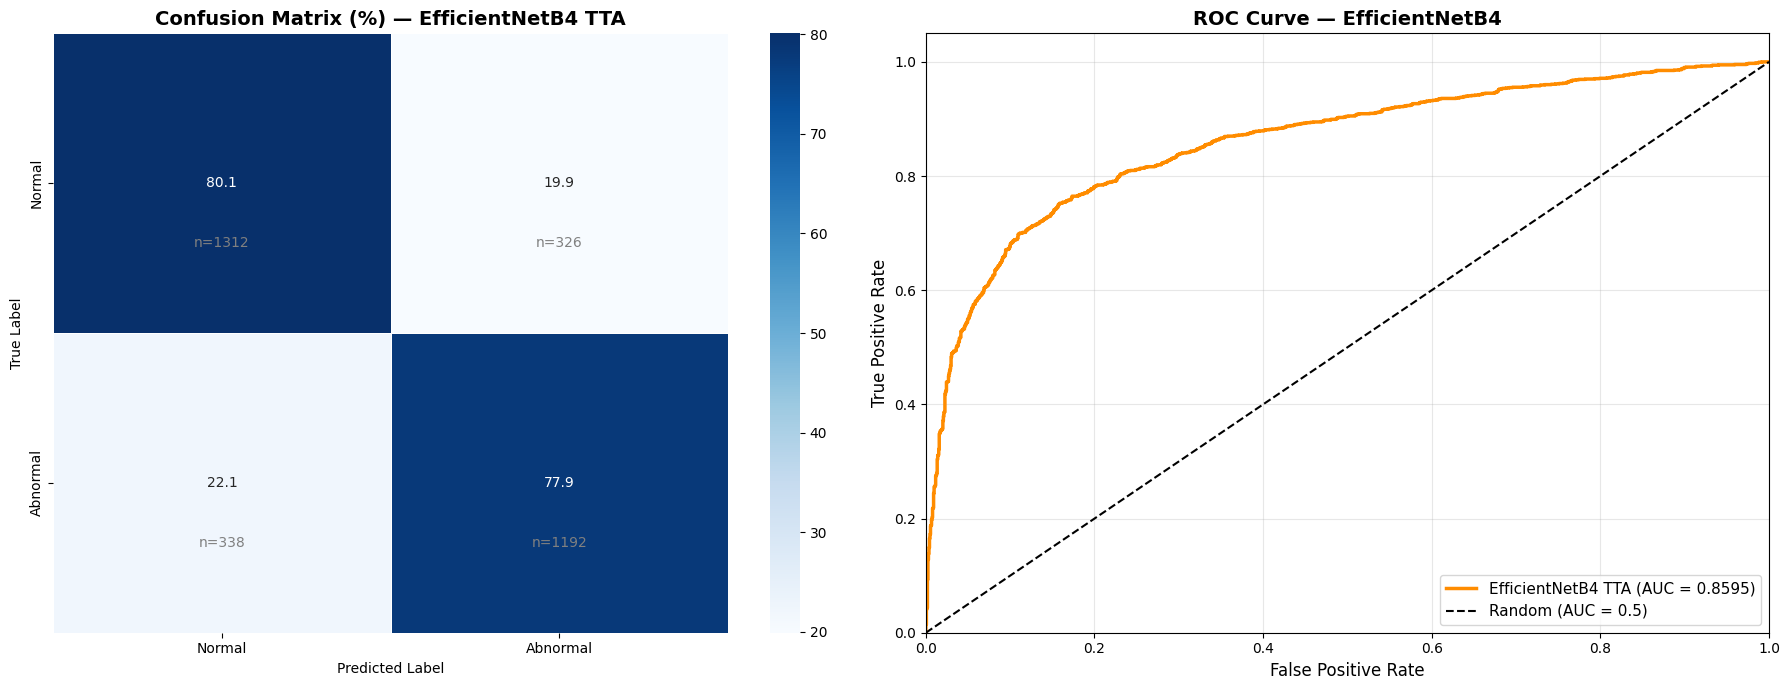

✓ Plots saved


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Confusion Matrix
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Normal', 'Abnormal'],
            yticklabels=['Normal', 'Abnormal'],
            ax=axes[0], linewidths=0.5)
for i in range(2):
    for j in range(2):
        axes[0].text(j+0.5, i+0.7, f'n={cm[i,j]}',
                     ha='center', va='center', fontsize=10, color='gray')
axes[0].set_title('Confusion Matrix (%) — EfficientNetB4 TTA', fontsize=14, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_proba_tta)
roc_auc_val = auc(fpr, tpr)
axes[1].plot(fpr, tpr, lw=2.5, color='darkorange', label=f'EfficientNetB4 TTA (AUC = {roc_auc_val:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5)')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title('ROC Curve — EfficientNetB4', fontsize=14, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/efficientnet_evaluation.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Plots saved")

## 16. Classification Report

In [ ]:
print("CLASSIFICATION REPORT:")
print(classification_report(y_val, y_pred_final,
                             target_names=['Normal', 'Abnormal'], digits=4))

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Normal     0.7952    0.8010    0.7981      1638
    Abnormal     0.7852    0.7791    0.7822      1530

    accuracy                         0.7904      3168
   macro avg     0.7902    0.7900    0.7901      3168
weighted avg     0.7904    0.7904    0.7904      3168



## 17. Save Model and All Artifacts

In [ ]:
SAVE_PATH = '/kaggle/working/efficientnet_mura_finetuned.keras'
best_model.save(SAVE_PATH)
print(f"✓ Final model saved: {SAVE_PATH}")

artifacts = [
    '/kaggle/working/efficientnet_final_metrics.csv',
    '/kaggle/working/training_history_efficientnet.png',
    '/kaggle/working/efficientnet_evaluation.png',
    '/kaggle/working/phase1_log.csv',
    '/kaggle/working/phase2_log.csv',
]
print("\nFiles ready for download in Output panel:")
for f in artifacts:
    if os.path.exists(f):
        print(f"  ✓ {os.path.basename(f)}")

print("\n✓ Download all files from Output panel on the right")

✓ Final model saved: /kaggle/working/efficientnet_mura_finetuned.keras

Files ready for download in Output panel:
  ✓ efficientnet_final_metrics.csv
  ✓ training_history_efficientnet.png
  ✓ efficientnet_evaluation.png
  ✓ phase1_log.csv
  ✓ phase2_log.csv

✓ Download all files from Output panel on the right
